In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [4]:
model = ChatOpenAI(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("Grok_Api_key"),
    base_url="https://api.groq.com/openai/v1"
)

In [5]:
class JokeState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [ ]:
def joke_generate(state: JokeState):
    topic = state['topic']

    prompt = f'Generate a joke on the topic {topic}'
    joke = model.invoke(prompt).content

    return {'joke':joke}


def explanation_generate(state:JokeState):

    prompt = f'Write the explanation for the joke {state["joke"]}'
    explanation = model.invoke(prompt).content

    return {'explanation': explanation}

In [7]:
graph = StateGraph(JokeState)

graph.add_node('joke_generate', joke_generate)
graph.add_node('explanation_generate', explanation_generate)


graph.add_edge(START, 'joke_generate')
graph.add_edge('joke_generate', 'explanation_generate')
graph.add_edge('explanation_generate', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)


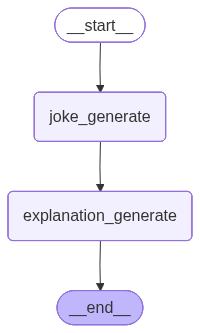

In [8]:
workflow

In [10]:
config = {"configurable":{'thread_id':'1'}}

workflow.invoke({"topic":'piza'}, config=config)

{'topic': 'piza',
 'joke': AIMessage(content='Why did the pizza go to therapy?\n\nBecause it was feeling crusty under the pressure.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 43, 'total_tokens': 62, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'queue_time': 0.006031687, 'prompt_time': 0.002906748, 'completion_time': 0.024108287, 'total_time': 0.027015035}, 'model_provider': 'openai', 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'id': 'chatcmpl-5e011efb-d8a1-4699-b8f1-57666c1749ee', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f6429-0427-71f1-bf44-6505b62155a5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 19, 'total_tokens': 62, 'input_token_details': {}, 'output_token_details': {}}),
 'explanation': AIMessage(content='This joke content utilizes wordplay on the phrase "fee

In [11]:
workflow.get_state(config)

StateSnapshot(values={'topic': 'piza', 'joke': AIMessage(content='Why did the pizza go to therapy?\n\nBecause it was feeling crusty under the pressure.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 43, 'total_tokens': 62, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'queue_time': 0.006031687, 'prompt_time': 0.002906748, 'completion_time': 0.024108287, 'total_time': 0.027015035}, 'model_provider': 'openai', 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'id': 'chatcmpl-5e011efb-d8a1-4699-b8f1-57666c1749ee', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f6429-0427-71f1-bf44-6505b62155a5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 19, 'total_tokens': 62, 'input_token_details': {}, 'output_token_details': {}}), 'explanation': AIMessage(content='This joke content utilizes wordplay

In [13]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'piza', 'joke': AIMessage(content='Why did the pizza go to therapy?\n\nBecause it was feeling crusty under the pressure.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 43, 'total_tokens': 62, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'queue_time': 0.006031687, 'prompt_time': 0.002906748, 'completion_time': 0.024108287, 'total_time': 0.027015035}, 'model_provider': 'openai', 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'id': 'chatcmpl-5e011efb-d8a1-4699-b8f1-57666c1749ee', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f6429-0427-71f1-bf44-6505b62155a5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 19, 'total_tokens': 62, 'input_token_details': {}, 'output_token_details': {}}), 'explanation': AIMessage(content='This joke content utilizes wordpla

In [15]:
config2 = {"configurable":{'thread_id':'2'}}

workflow.invoke({"topic":'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': AIMessage(content="Why did the spaghetti join a band? \n\nBecause it wanted to be the 'twisted' lead guitar, but it kept getting tangled up in its own ego.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 42, 'total_tokens': 76, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'queue_time': 0.033593155, 'prompt_time': 0.002078508, 'completion_time': 0.057710644, 'total_time': 0.059789152}, 'model_provider': 'openai', 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'id': 'chatcmpl-55661815-36f5-4a65-b28a-4e0ba0c88cca', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f642e-ac1d-7300-b0cc-c5f9091bf7f4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 34, 'total_tokens': 76, 'input_token_details': {}, 'output_token_details': {}}),
 'explanation': AIMessage(content='He

In [16]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': AIMessage(content="Why did the spaghetti join a band? \n\nBecause it wanted to be the 'twisted' lead guitar, but it kept getting tangled up in its own ego.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 42, 'total_tokens': 76, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'queue_time': 0.033593155, 'prompt_time': 0.002078508, 'completion_time': 0.057710644, 'total_time': 0.059789152}, 'model_provider': 'openai', 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'id': 'chatcmpl-55661815-36f5-4a65-b28a-4e0ba0c88cca', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f642e-ac1d-7300-b0cc-c5f9091bf7f4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 34, 'total_tokens': 76, 'input_token_details': {}, 'output_token_details': {}}), 'explanation': AI

In [18]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': AIMessage(content="Why did the spaghetti join a band? \n\nBecause it wanted to be the 'twisted' lead guitar, but it kept getting tangled up in its own ego.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 42, 'total_tokens': 76, 'completion_tokens_details': None, 'prompt_tokens_details': None, 'queue_time': 0.033593155, 'prompt_time': 0.002078508, 'completion_time': 0.057710644, 'total_time': 0.059789152}, 'model_provider': 'openai', 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'id': 'chatcmpl-55661815-36f5-4a65-b28a-4e0ba0c88cca', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f642e-ac1d-7300-b0cc-c5f9091bf7f4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 34, 'total_tokens': 76, 'input_token_details': {}, 'output_token_details': {}}), 'explanation': A